In [ ]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [20]:
df = pd.read_csv("datasets/train.csv")


In [ ]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [24]:
columns = df.columns
print(columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [ ]:
# Rows and columns
df.shape

(891, 12)

In [49]:
# information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [35]:
df.describe()
# df["Age"].mean()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [29]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

29.11242424242424
26.0
0.42
80.0
Axes(0.125,0.11;0.775x0.77)


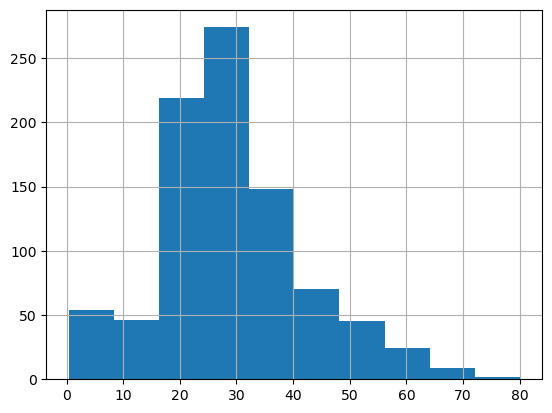

In [48]:
print(df['Age'].mean())
print(df['Age'].median())
print(df['Age'].min())
print(df['Age'].max())
print(df['Age'].hist())



In [40]:
df.groupby("Pclass")["Age"].median()

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

In [41]:
df.groupby("Sex")["Age"].median()


Sex
female    27.0
male      29.0
Name: Age, dtype: float64

In [47]:
df.groupby(["Pclass", "Sex"])["Age"].median()


Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [43]:
df['Age'] = df['Age'].fillna(df.groupby(['Pclass', "Sex"])["Age"].transform("median"))

In [46]:
df["Age"].isnull().sum()

np.int64(0)

In [50]:
df["Cabin"].notna().groupby(df["Survived"]).mean()

Survived
0    0.123862
1    0.397661
Name: Cabin, dtype: float64

In [51]:
df.groupby("Survived")["Cabin"].apply(lambda x: x.notna().mean())

Survived
0    0.123862
1    0.397661
Name: Cabin, dtype: float64

In [53]:
df["HasCabin"] = df["Cabin"].notna().astype(int)
df.groupby("HasCabin")["Survived"].mean()

HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64

In [54]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [55]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [56]:
df.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [57]:
pd.crosstab(df["Sex"], df["Pclass"], values=df["Survived"], aggfunc="mean")

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [58]:
df.groupby(pd.cut(df["Age"], bins=[0,12,18,35,60,100]))["Survived"].mean()

C:\Users\anmol\AppData\Local\Temp\ipykernel_16256\4255032903.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["Age"], bins=[0,12,18,35,60,100]))["Survived"].mean()


Age
(0, 12]      0.579710
(12, 18]     0.428571
(18, 35]     0.357977
(35, 60]     0.384259
(60, 100]    0.227273
Name: Survived, dtype: float64

In [59]:
pd.pivot_table(
    df,
    values="Survived",
    index="Sex",
    columns="Pclass",
    aggfunc="mean"
)

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [60]:
pd.pivot_table(
    df,
    values="Survived",
    index="Sex",
    columns=pd.cut(df["Age"], bins=[0,12,18,35,60,100]),
    aggfunc="mean"
)

C:\Users\anmol\AppData\Local\Temp\ipykernel_16256\2266739005.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


Age,"(0, 12]","(12, 18]","(18, 35]","(35, 60]","(60, 100]"
Sex,,,,,
female,0.593750,0.750000,0.751445,0.771429,1.000000
male,0.567568,0.088235,0.158358,0.198630,0.105263


In [61]:
df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: >

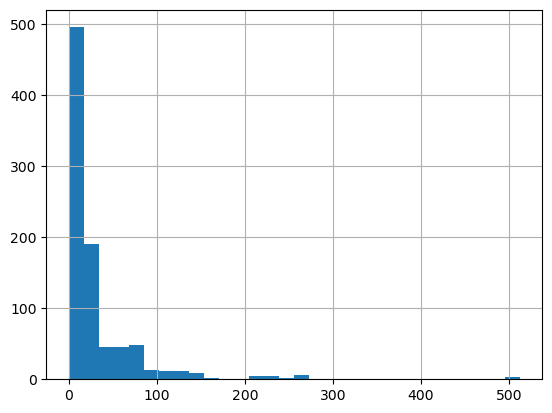

In [66]:
df["Fare"].hist(bins=30)

In [67]:
df.groupby(pd.qcut(df["Fare"], 4))["Survived"].mean()

C:\Users\anmol\AppData\Local\Temp\ipykernel_16256\1256130791.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["Fare"], 4))["Survived"].mean()


Fare
(-0.001, 7.91]     0.197309
(7.91, 14.454]     0.303571
(14.454, 31.0]     0.454955
(31.0, 512.329]    0.581081
Name: Survived, dtype: float64

In [62]:
df.groupby("Pclass")["Fare"].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

In [63]:
df.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [77]:
pd.crosstab(df["Embarked"], df["Pclass"])

Pclass,1,2,3
Embarked,,,
C,85,17,66
Q,2,3,72
S,127,164,353


In [64]:
df.groupby("SibSp")["Survived"].mean()

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

In [65]:
df.groupby("Parch")["Survived"].mean()

Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64

In [68]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [69]:
df["FamilySize"].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

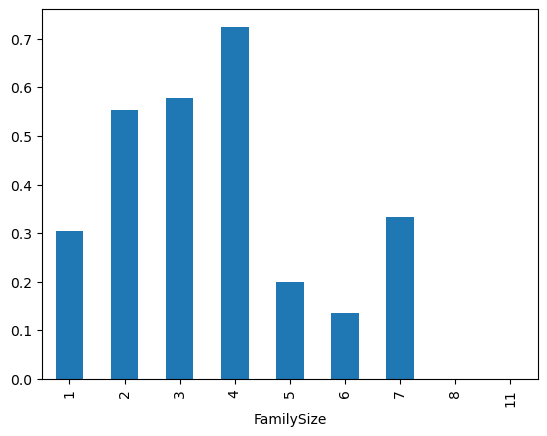

In [73]:
df.groupby("FamilySize")["Survived"].mean().plot(kind="bar")
plt.show()

In [74]:
df.groupby("FamilySize")["Survived"].mean()


FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [75]:
df["FamilySize"].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [76]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [78]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  HasCabin     891 non-null    int64  
 13  FamilySize   891 non-null    int64  
 14  IsAlone      891 non-null    int64  
dtypes: float64(2), int64(8), object(5)
memory usage: 104.5+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
HasCabin         0
FamilySize       0
IsAlone          0
dtype: int64

In [79]:
df = df.drop("Cabin", axis=1)

In [80]:
df["Embarked"].mode()

0    S
Name: Embarked, dtype: object

In [81]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [82]:
df = df.drop("PassengerId", axis=1)

In [83]:
df = df.drop("Name", axis=1)

In [84]:
df = df.drop("Ticket", axis=1)

In [85]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    object 
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    891 non-null    object 
 8   HasCabin    891 non-null    int64  
 9   FamilySize  891 non-null    int64  
 10  IsAlone     891 non-null    int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 76.7+ KB


Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
HasCabin      0
FamilySize    0
IsAlone       0
dtype: int64

Key Findings:
- Females had much higher survival rates than males.
- First-class passengers survived more often than third-class passengers.
- Higher fare passengers survived more often.
- Passengers with cabin information survived more often.
- Small families (2–4 members) had the highest survival rates.
- Children survived more often than adults.
- Cherbourg passengers showed higher survival rates, likely due to a larger proportion of first-class passengers.

### MACHINE LEARNING MODEL WORK


In [98]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [105]:
df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

In [106]:
y = df["Survived"]
X = df.drop("Survived", axis=1)

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [108]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,2,0,True,False,True
1,1,1,38.0,1,0,71.2833,1,2,0,False,False,False
2,1,3,26.0,0,0,7.9250,0,1,1,False,False,True
3,1,1,35.0,1,0,53.1000,1,2,0,False,False,True
4,0,3,35.0,0,0,8.0500,0,1,1,True,False,True


In [109]:
X_train.shape


(712, 11)

In [110]:
X_test.shape

(179, 11)

In [111]:
X.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize',
       'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [112]:
model = LogisticRegression(max_iter=1000)

In [113]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [114]:
X.dtypes

Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
HasCabin        int64
FamilySize      int64
IsAlone         int64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object

In [115]:
predictions = model.predict(X_test)

In [116]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [117]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[91 14]
 [20 54]]


In [118]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [119]:
predictions = model.predict(X_test)

from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, predictions))

0.8100558659217877


In [120]:
for feature, coef in zip(X.columns, model.coef_[0]):
    print(feature, coef)

Pclass -0.7763294091585217
Age -0.032588121712399984
SibSp -0.20942637728735086
Parch -0.00465694710447453
Fare 0.0015366445890315846
HasCabin 0.5557758173299375
FamilySize -0.2458582295029031
IsAlone -0.604230540945699
Sex_male -2.5232315258015348
Embarked_Q -0.13688191646396128
Embarked_S -0.32318854834563226


In [121]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, predictions))

[[91 14]
 [20 54]]


### DECISION TREE CLASSIFIER


In [123]:
from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier

In [124]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [125]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [127]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:",
      accuracy_score(y_test, pred_dt))

Decision Tree Accuracy: 0.7821229050279329


In [130]:
for feature, importance in zip(X.columns, dt.feature_importances_):
    print(feature, importance)

Pclass 0.10186517487522907
Age 0.20832332304255993
SibSp 0.03702599926051674
Parch 0.013491317700418736
Fare 0.2269610144003023
HasCabin 0.03658766776238367
FamilySize 0.04706636943338205
IsAlone 0.0
Sex_male 0.30700857920355257
Embarked_Q 0.00730232565927727
Embarked_S 0.014368228662377773


In [131]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [129]:
print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, pred_rf)
)

Random Forest Accuracy: 0.8268156424581006


In [132]:
for feature, importance in zip(X.columns, rf.feature_importances_):
    print(feature, importance)

Pclass 0.06895022009323258
Age 0.24720382722749887
SibSp 0.028854725682491155
Parch 0.023118573170101943
Fare 0.24870013251723277
HasCabin 0.03662861375218038
FamilySize 0.04721154037344308
IsAlone 0.010585924895887945
Sex_male 0.25308074538566344
Embarked_Q 0.010411854621431118
Embarked_S 0.02525384228083671


In [133]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:",
      accuracy_score(y_test, predictions))

print("Decision Tree:",
      accuracy_score(y_test, pred_dt))

print("Random Forest:",
      accuracy_score(y_test, pred_rf))

Logistic Regression: 0.8100558659217877
Decision Tree: 0.7821229050279329
Random Forest: 0.8268156424581006


In [134]:
for feature, importance in zip(X.columns, rf.feature_importances_):
    print(feature, round(importance, 4))

Pclass 0.069
Age 0.2472
SibSp 0.0289
Parch 0.0231
Fare 0.2487
HasCabin 0.0366
FamilySize 0.0472
IsAlone 0.0106
Sex_male 0.2531
Embarked_Q 0.0104
Embarked_S 0.0253
